In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded))
print(f"File uploaded: {file_name}")

Saving archive (2).zip to archive (2).zip
File uploaded: archive (2).zip


In [4]:
import zipfile
import os

# Define the extraction directory
extract_dir = "/content/extracted_files"
os.makedirs(extract_dir, exist_ok=True)

# Unzip the uploaded file
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Find the Excel file in the extracted directory (assuming there's only one .xlsx file)
extracted_file_path = None
for root, _, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.xlsx'):
            extracted_file_path = os.path.join(root, file)
            break
    if extracted_file_path:
        break

if extracted_file_path:
    print(f"Excel file extracted to: {extracted_file_path}")
    # Now you can use extracted_file_path to read the Excel file
else:
    print("No Excel file found in the archive.")

Excel file extracted to: /content/extracted_files/Online Retail.xlsx


In [5]:
df = pd.read_excel(extracted_file_path, engine='openpyxl')
print("--- DataFrame Head ---")
print(df.head())
print("\n--- DataFrame Info ---")
df.info()

--- DataFrame Head ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count

In [7]:
df_cleaned = df.copy()

df_cleaned.dropna(subset=['CustomerID'], inplace=True)

df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)

df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]

df_cleaned['TotalAmount'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

print(f"Original size: {len(df)} rows")
print(f"Cleaned size: {len(df_cleaned)} rows")
print("\nCleaned Data Head:")
print(df_cleaned.head())

Original size: 541909 rows
Cleaned size: 397884 rows

Cleaned Data Head:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39       17850  United Kingdom        20.34  


In [8]:
latest_date = df_cleaned['InvoiceDate'].max()

SNAPSHOT_DATE = latest_date + dt.timedelta(days=1)
print(f"Latest Transaction Date: {latest_date}")
print(f"Snapshot Date for Recency: {SNAPSHOT_DATE}")

Latest Transaction Date: 2011-12-09 12:50:00
Snapshot Date for Recency: 2011-12-10 12:50:00


In [9]:
rfm_df = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (SNAPSHOT_DATE - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm_df.rename(columns={'InvoiceDate': 'Recency',
                       'InvoiceNo': 'Frequency',
                       'TotalAmount': 'Monetary'}, inplace=True)

print("RFM DataFrame Head:")
print(rfm_df.head())
print("\nRFM DataFrame Descriptive Statistics:")
print(rfm_df.describe().round(2))

RFM DataFrame Head:
            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40

RFM DataFrame Descriptive Statistics:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


In [10]:
rfm_log = np.log(rfm_df)

print("Log-Transformed Data Head:")
print(rfm_log.head().round(2))

Log-Transformed Data Head:
            Recency  Frequency  Monetary
CustomerID                              
12346          5.79       0.00     11.25
12347          0.69       1.95      8.37
12348          4.32       1.39      7.49
12349          2.94       0.00      7.47
12350          5.74       0.00      5.81


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_df.columns, index=rfm_df.index)

print("\nStandardized Data Descriptive Statistics (Should be close to 0 and 1):")
print(rfm_scaled_df.describe().round(2))


Standardized Data Descriptive Statistics (Should be close to 0 and 1):
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -2.63      -1.05     -4.18
25%      -0.61      -1.05     -0.68
50%       0.11      -0.28     -0.06
75%       0.83       0.74      0.65
max       1.51       4.88      4.72


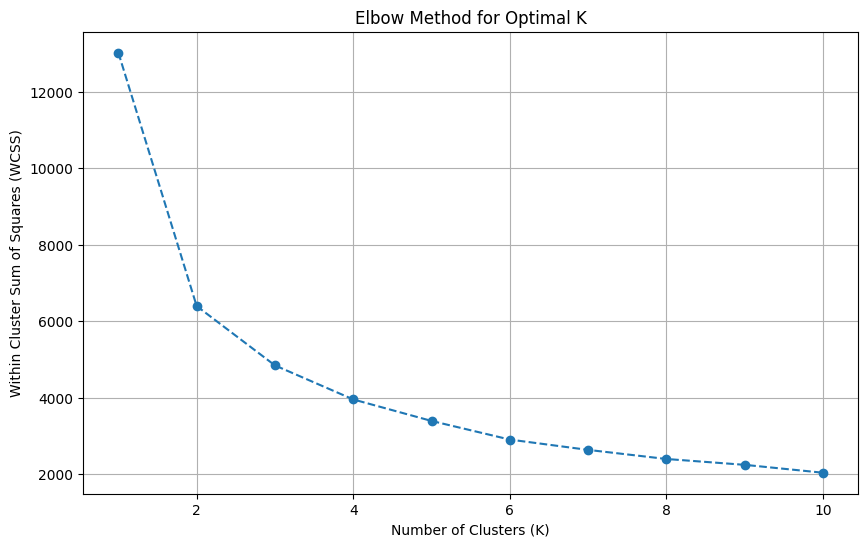

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

In [14]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init='auto')

clusters = kmeans_final.fit_predict(rfm_scaled)

rfm_df['Cluster'] = clusters

print(rfm_df.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346           326          1  77183.60        3
12347             2          7   4310.00        1
12348            75          4   1797.24        3
12349            19          1   1757.55        0
12350           310          1    334.40        2


In [15]:
cluster_profiles = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(0)

print("--- Cluster Profiles ---")
print(cluster_profiles)

--- Cluster Profiles ---
        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0          22.0       2.0    468.0   795
1          10.0      13.0   7678.0   756
2         190.0       1.0    344.0  1508
3          71.0       4.0   1733.0  1279
